# Fall 2025 MSS Drifter Deployment Plan

We plan to deploy several drifters in NAFO subdivisions 2HJ3K and 3KLNO.

Tentative Dates: December 1-20, 2025

## Goals
* Create an inventory of drifter data on NL Shelf for model evaluation 
* Transmit data to GTS to support operational weather and ocean forecasting
* Examine bifurcation of Labrador current along Bonvista transect


## Drifter Inventory
| Name       | Type    | Quantity | Data collected                |
|------------|---------|----------|-------------------------------|
| iSVP       | Drogued | 4        | Position/Temperature/Pressure |



## Deployment Areas

1. 2HJ3K
2. 3KLNO


In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import numpy as np
import xarray as xr

import shapefile

%matplotlib inline

In [2]:
def get_nafo_divisions():
    """ Will generate a dict with NAFO division shapes.
    Example to access info:
    In [14]: dict['2J']['lat']
    Out[14]: [55.33, 55.33, 52.25, 52.25]

    ** Needs to be expanded with other divisions **
    (see map_extract_nafo.py for help getting polygons)

    """

    # 0B
    xlon = [-62.466, -57.634, -57.8, -57.818, -58.033, -57.557, -57.352, -57.218, -57.218, -57.218, -59, -65, -66.259]
    xlat = [66.25, 66.25, 64.25, 64.072, 63.582, 62.5, 62, 61, 60.75, 60.2, 61, 61, 61.866]
    div0B = {'lat' : xlat, 'lon' : xlon}

    # 1C
    xlon = [-53.342, -57.634, -57.8, -52.044]
    xlat = [66.25, 66.25, 64.25, 64.25]
    div1C = {'lat' : xlat, 'lon' : xlon}

    # 1D
    xlon = [-52.044, -57.8, -57.818, -58.033, -57.557, -50.037]
    xlat = [64.25, 64.25, 64.072, 63.582, 62.5, 62.5]
    div1D = {'lat' : xlat, 'lon' : xlon}

    # 1E
    xlon = [-50.037, -57.557, -57.352, -57.218, -46.153]
    xlat = [62.5, 62.5, 62, 60.75, 60.75]
    div1E = {'lat' : xlat, 'lon' : xlon}

    # 1F
    xlon = [-46.153, -57.218, -57.2187, -42, -42, -44, -44]
    xlat = [60.75, 60.75, 60.2, 52.25, 59, 59, 60.157]
    div1F = {'lat' : xlat, 'lon' : xlon}    

    # 2G
    xlon = [-64.5, -64.5, -59, -52, -61.9]
    xlat = [60.3, 61, 61, 57.667, 57.667]
    div2G = {'lat' : xlat, 'lon' : xlon}

    # 2H
    xlon = [-61.924, -52.010, -47.531, -60.382]
    xlat = [57.667, 57.667, 55.333, 55.333]
    div2H = {'lat' : xlat, 'lon' : xlon}

    # 2J
    xlon = [-59.778, -47.529, -42, -55.712]
    xlat = [55.33, 55.33, 52.25, 52.25]
    div2J = {'lat' : xlat, 'lon' : xlon}

    # 3K (no land)
    xlon = [-55.425, -55.425, -42, -42, -53.466]
    xlat = [51.583, 52.25, 52.25, 49.25, 49.25]
    div3K = {'lat' : xlat, 'lon' : xlon}

    # 3K-xtended (point on land to close the box)
    xlon = [-55.425, -55.425, -42, -42, -53.466, -57.5]
    xlat = [51.583, 52.25, 52.25, 49.25, 49.25, 49.25]
    div3Kx = {'lat' : xlat, 'lon' : xlon}

    # 3L
    xlon = [-53.466, -46.5, -46.5, -54.5, -54.2]
    xlat = [49.25, 49.25, 46, 46, 46.815]
    div3L = {'lat' : xlat, 'lon' : xlon}

    # 3N
    xlon = [-51, -46.5, -46.5, -50, -51, -51]
    xlat = [46, 46, 39, 39, 39.927, 46]
    div3N = {'lat' : xlat, 'lon' : xlon}

    # 3M
    xlon = [-42, -46.5, -46.5, -42, -42]
    xlat = [49.25, 49.25, 39, 39, 49.25]
    div3M = {'lat' : xlat, 'lon' : xlon}

    # 3O
    xlon = [-54.5, -51, -51, -54.5, -54.5]
    xlat = [46, 46, 39.927, 43.064, 46]
    div3O = {'lat' : xlat, 'lon' : xlon}

    #3Pn
    xlon = [-57.523, -59.308, -59.569, -58.817]
    xlat = [47.631, 47.620, 47.477, 46.843]
    div3Pn = {'lat' : xlat, 'lon' : xlon}
    
    #3Ps
    xlon = [-57.523, -58.82, -54.5, -54.5, -54.0]
    xlat = [47.631, 46.843, 43.064, 46, 47.7]
    div3Ps = {'lat' : xlat, 'lon' : xlon}

    #4R
    xlon = [-59.308, -59.571, -60, -60, -57.114]
    xlat = [47.62, 47.473, 47.883, 49.418, 51.412]
    div4R = {'lat' : xlat, 'lon' : xlon}

    #4S
    xlon = [-60, -64.667, -67.304, -67.304, -57.130, -60]
    xlat = [47.835, 49.417, 49.417, 51.4, 51.4, 49.416]
    div4S = {'lat' : xlat, 'lon' : xlon}

    #4T
    xlon = [-60, -64.667, -67.304, -65.409, -61.384, -60.413]
    xlat = [47.835, 49.416, 49.416, 47.075, 45.583, 47.039]
    div4T = {'lat' : xlat, 'lon' : xlon}

    #4Vn
    xlon = [-60.41, -60., -57.45, -60.]
    xlat = [47.05, 47.83, 45.67, 45.67]
    div4Vn = {'lat' : xlat, 'lon' : xlon}

    #4Vs
    xlon = [-60.18, -60.15, -57.45, -50, -59, -59., -60, -60]
    xlat = [45.78, 45.70, 45.67, 39, 39, 44.17, 44.17, 45.67]
    div4Vs = {'lat' : xlat, 'lon' : xlon}

    #4W
    xlon = [-63.5, -63.33, -63.33, -59, -59, -60, -60]
    xlat = [44.48, 44.33, 39, 39, 44.17, 44.17, 45.67]
    div4W = {'lat' : xlat, 'lon' : xlon}

    #4X
    xlon = [-66.91, -66.91, -67.41, -67.74, -67.3, -66, -65.67, -65.67, -63.33, -63.33, -63.5] 
    xlat = [45.05, 43.84, 43.84, 42.88, 42.33, 42.33, 42, 39, 39, 44.33, 44.48]
    div4X = {'lat' : xlat, 'lon' : xlon}

    #5Y
    xlon = [-71, -66.903, -66.903, -67.407, -67.744, -67.303, -70, -70, -71]
    xlat = [45.059, 45.059, 43.833, 43.833, 42.887, 42.334, 42.334, 41.7, 41.7]
    div5Y = {'lat' : xlat, 'lon' : xlon}

    #5Ze
    xlon = [-70, -70, -66, -65.667, -65.667, -70, -70]
    xlat = [41.967, 42.333, 42.333, 42.0, 39.0, 39.0, 41.667]
    div5Ze = {'lat' : xlat, 'lon' : xlon}   
    
    #5Zw
    xlon = [-71.667, -71.667, -70, -70]
    xlat = [41.346, 39, 39, 41.667]
    div5Zw = {'lat' : xlat, 'lon' : xlon}
               
    dict = {}
    dict['0B'] = div0B
    dict['1C'] = div1C
    dict['1D'] = div1D
    dict['1E'] = div1E
    dict['1F'] = div1F
    dict['2G'] = div2G
    dict['2H'] = div2H
    dict['2J'] = div2J
    dict['3K'] = div3K
    dict['3Kx'] = div3Kx
    dict['3L'] = div3L
    dict['3N'] = div3N
    dict['3M'] = div3M
    dict['3O'] = div3O
    dict['3Ps'] = div3Ps
    dict['3Pn'] = div3Pn
    dict['3O'] = div3O
    dict['4R'] = div4R
    dict['4S'] = div4S
    dict['4T'] = div4T
    dict['4Vn'] = div4Vn
    dict['4Vs'] = div4Vs
    dict['4W'] = div4W
    dict['4X'] = div4X
    dict['5Y'] = div5Y
    dict['5Ze'] = div5Ze
    dict['5Zw'] = div5Zw

    return dict

In [3]:
lat_min=38
lon_min=-65
lat_max=60
lon_max=-40

In [4]:
# Glorys climatology
f='/nfs/nafc-store-0.ent.dfo-mpo.ca/GLORYS12_subsets/Allvars_glorys12_1993-2018_daily12.nc'
d = xr.open_dataset(f)
dsel = d.isel(depth=0).sel(latitude=slice(lat_min,lat_max), longitude=slice(lon_min, lon_max)).mean(dim='time')
uvel = dsel.uo.values
vvel = dsel.vo.values
lat = dsel.latitude.values
lon = dsel.longitude.values
lon, lat = np.meshgrid(lon, lat)

In [5]:
# etopo file
ef = '/home/soontiensn/data/ocn-nav/ETOPO1_Bed_g_gmt4.grd'
etopo = xr.open_dataset(ef)
esel = etopo.sel(x=slice(lon_min, lon_max), y=slice(lat_min, lat_max))

In [6]:
def plot_quivers(ax, xvel,yvel,lat,lon,st=10):
    mag = np.sqrt(xvel**2+yvel**2)
    mesh=ax.pcolormesh(lon,lat,mag,vmin=0,vmax=1,cmap='YlGnBu_r', transform=ccrs.PlateCarree())
    q=ax.quiver(lon[::st,::st],lat[::st,::st],xvel[::st,::st],yvel[::st,::st],
                  scale=10,color='lightgrey', transform=ccrs.PlateCarree())
    ax.quiverkey(q,0.05,0.4,0.5,'0.5 m/s',color='lightgrey')
    cbar=plt.colorbar(mesh, ax=ax)
    cbar.set_label('speed [m/s]')

In [7]:
def plot_transects(ax,transects):
    for transect in transects:
        lons = np.array([transects[transect]['start'][0],
                         transects[transect]['end'][0]])
        lats = np.array([transects[transect]['start'][1],
                         transects[transect]['end'][1]])
        ax.plot(lons, lats,'-r', transform=ccrs.PlateCarree())

In [8]:
def plot_stations(ax,stations):
    for station in stations:
        lon = stations[station][0]
        lat = stations[station][1]
        marker='o'
        #if 'BB' in station:
        #    marker='o'
        #else:
        #    marker = 's'
        ax.plot(lon, lat,marker, label=station, markeredgecolor='k',markersize=10, transform=ccrs.PlateCarree())

In [9]:
def plot_areas(ax, areas, color='k'):
    for area in areas:
        lons = areas[area]['lon']
        lats = areas[area]['lat']
        ax.plot(lons, lats,'-', color=color, transform=ccrs.PlateCarree())

In [10]:
def plot_bathymetry( ax, etopo):
    lons = etopo.x.values
    lats = etopo.y.values
    lons, lats = np.meshgrid(lons,lats)
    bathy = etopo.z.values
    levels = [-500, -200, -100,]
    CS = ax.contour(lons,lats,bathy,levels, linestyles='solid', linewidth=0.1,colors='black',transform=ccrs.PlateCarree())
    ax.clabel(CS, CS.levels, inline=True, fmt='%1.0f', fontsize=12)

# Plots

In [11]:
transects = {
    'BI': {'start': [-61.305, 57.0583333333333],
           'end': [-58.5833333333333,57.8833333333333],},
    'MB': {'start': [-58.5133333333333,55.2166666666667],
           'end': [-56.51,56.0783333333333]},
    'BB': {'start': [-52.9666666666667,48.7333333333333],
           'end': [-47.9466666666667,50.3316666666667]},
    'SI': {'start': [-55.65,53.233],
           'end': [-52.5,55.067]},
    'FC': {'start':[ -52.8316666666667, 47],
           'end': [-42, 47]},
    #'S27': {'start': [-52.5866666666667,47.5466666666667],
    #        'end': [-48.41,48.4333333333333]}
}
stations = {
    #'BI-09': [-58.5833333333333,57.8833333333333],
    #'MB-09': [-57.2216666666667,55.77],
    #'MB-10': [-56.9833333333333,55.8716666666667],
    #'MB-11': [-56.7416666666667,55.9783333333333],
    #'MB-12': [-56.51,56.0783333333333],
    #'BB-01': [-52.9666666666667,48.7333333333333],
    #'BB-02': [-52.75,48.8],
    #'BB-03 \n 3 Stokes \n 1 Code/Davis': [-52.65,48.8333333333333],
    #'BB-04 \n 3 Stokes \n 1 Code/Davis': [-52.4,48.9166666666667],
    #'BB-05': [-52.0666666666667,49.025],
    #'BB-06': [-51.83, 49.10],
    #'BB-07': [-51.54, 49.19],
    'BB-08': [-51.28,49.28],
    #'BB-11': [-50.0166666666667,49.6833333333333],
    #'BB-13': [-49, 50], 
    #'BB-14': [-48.4716666666667,50.1766666666667],
    #'BB-15': [-47.9466666666667,50.3316666666667],
    #'SI-01': [-55.650, 53.233 ],
    #'SI-02': [-55.500, 53.333 ],
    #'SI-03': [-55.357, 53.410 ],
    #'SI-04': [-55.145, 53.533 ],
    #'SI-05': [-55.000, 53.617 ],
    #'SI-06': [-54.777, 53.757 ], 
    #'SI-07': [-54.500, 53.917 ],
    'SI-11': [-53.500, 54.500 ],
    #'SI-12': [-53.250, 54.633 ],
    #'SI-13': [-53.000, 54.783 ],
    #'SI-14': [-52.500, 55.067 ],
    #'FC-06': [-51.485,47],
    #'FC-09': [-50,47],
    'WB-14': [-50.9916666666667,51.7883333333333],
    'FC-13': [-47.8166666666667,47],
    #'FC-15': [-47.25,47],
    #'FC-25': [-44.9883333333333,47],
    #'FC-26': [-44.772,47.000],
    #'FC-31': [-43.833,47.000],
    #'FC-38': [-42,47], 
    #'S27-05': [-51.65,47.74],
    #'S27-10': [-50.48,47.99]
}
areas = get_nafo_divisions()
areas = {area: areas[area] for area in ['3K', '3N', '3L', '3O', '2J', '2H']}

/home/soontiensn/miniconda-new/envs/griddrift/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'linewidth'
  result = super().contour(*args, **kwargs)


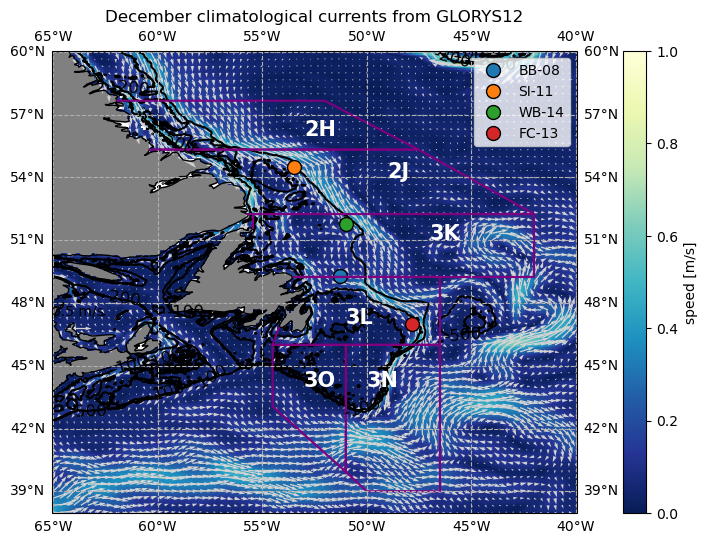

In [12]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(1,1,1,projection = ccrs.PlateCarree())
plot_quivers(ax,uvel,vvel,lat, lon,st=4)
plot_bathymetry( ax, esel)
#plot_transects(ax, transects)
plot_stations(ax, stations)
plot_areas(ax, areas, color='purple')

ax.text(-47,51, '3K', fontsize=15,color='white', fontweight='bold',)
ax.text(-49,54, '2J', fontsize=15,color='white', fontweight='bold',)
ax.text(-53,56, '2H', fontsize=15,color='white', fontweight='bold',)
ax.text(-51,47, '3L', fontsize=15,color='white', fontweight='bold',)
ax.text(-53,44, '3O', fontsize=15,color='white', fontweight='bold',)
ax.text(-50,44, '3N', fontsize=15,color='white', fontweight='bold',)
#ax.text(0.35,0.75, 'MB', fontsize=12,color='w', transform=ax.transAxes,fontweight='bold')
#ax.text(0.65,0.4, 'BB', fontsize=12,color='w', transform=ax.transAxes,fontweight='bold')
#ax.text(0.52,0.69, 'SI', fontsize=12,color='w', transform=ax.transAxes,fontweight='bold')
#ax.text(0.82,0.15, 'FC', fontsize=12,color='w', transform=ax.transAxes,fontweight='bold')
#ax.text(0.6,0.3, 'S27', fontsize=12,color='w', transform=ax.transAxes,fontweight='bold')
ax.set_title('December climatological currents from GLORYS12')
ax.legend(loc='upper right')

ax.coastlines()
ax.gridlines(draw_labels=True, ls='--')
ax.add_feature(cfeature.LAND, color='grey')

In [13]:
fig.savefig('FallMSS2025deploymentplanCurrents.png', bbox_inches='tight')

/home/soontiensn/miniconda-new/envs/griddrift/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'linewidth'
  result = super().contour(*args, **kwargs)


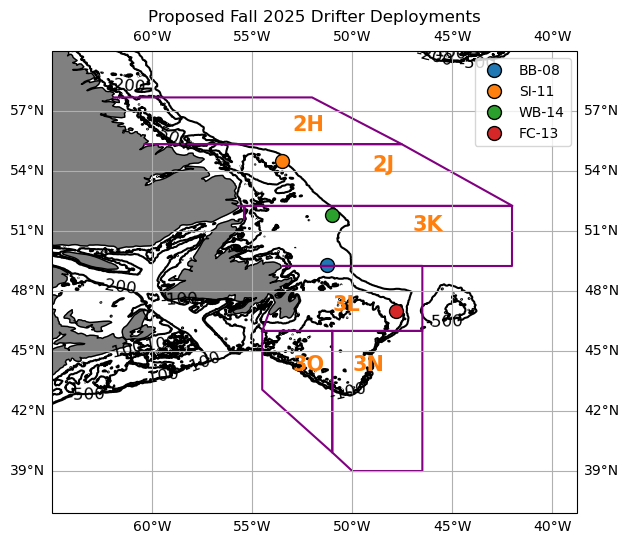

In [14]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(1,1,1,projection = ccrs.PlateCarree())
#plot_quivers(ax,uvel,vvel,lat, lon,st=3)
plot_bathymetry( ax, esel)
#plot_transects(ax, transects)
plot_stations(ax, stations)
plot_areas(ax, areas, color='purple')

ax.text(-47,51, '3K', fontsize=15,color='C1', fontweight='bold',)
ax.text(-49,54, '2J', fontsize=15,color='C1', fontweight='bold',)
ax.text(-53,56, '2H', fontsize=15,color='C1', fontweight='bold',)
ax.text(-51,47, '3L', fontsize=15,color='C1', fontweight='bold',)
ax.text(-53,44, '3O', fontsize=15,color='C1', fontweight='bold',)
ax.text(-50,44, '3N', fontsize=15,color='C1', fontweight='bold',)
ax.set_title('Proposed Fall 2025 Drifter Deployments')
ax.legend(loc='upper right')

ax.coastlines()
ax.gridlines(draw_labels=True)
ax.add_feature(cfeature.LAND, color='grey')


In [15]:
fig.savefig('Fall2025deploymentplan.png', bbox_inches='tight')